In [ ]:
import math
from dataclasses import dataclass
import torch.nn.functional as F

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import precision_score, recall_score, f1_score,fbeta_score
from sklearn.preprocessing import StandardScaler
from pygam import LinearGAM, s, te

# transformer package (pytorch)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [3]:
# importing and browsing data
csv_path = Path("..") / "Dataset" / "Outputs" / "CS2_model_input.csv"
df = pd.read_csv(csv_path)

print("Path:", csv_path.resolve())
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
display(df.head(5))

Path: /Users/peterpan/Documents/GitHub/Data-Science-Case-Study-1/Dataset/Outputs/CS2_model_input.csv
Shape: (70128, 24)

Columns: ['Zone', 'PM25', 'Datetime_UTC', 'fire_count_regional', 'frp_regional_sum', 'hfi_weighted', 'fwi_mean', 'fire_count_local', 'frp_local_sum', 'PM25_lag_1h', 'PM25_lag_6h', 'PM25_lag_24h', 'PM25_lag_48h', 'PM25_roll_24h_mean', 'PM25_roll_24h_max', 'PM25_roll_7d_mean', 'frp_roll_24h_sum', 'frp_roll_72h_sum', 'hour', 'day_of_week', 'month', 'is_wildfire_season', 'season', 'alert']

Dtypes:
 Zone                    object
PM25                   float64
Datetime_UTC            object
fire_count_regional    float64
frp_regional_sum       float64
hfi_weighted           float64
fwi_mean               float64
fire_count_local       float64
frp_local_sum          float64
PM25_lag_1h            float64
PM25_lag_6h            float64
PM25_lag_24h           float64
PM25_lag_48h           float64
PM25_roll_24h_mean     float64
PM25_roll_24h_max      float64
PM25_roll_7d_me

,Zone,PM25,Datetime_UTC,fire_count_regional,frp_regional_sum,hfi_weighted,fwi_mean,fire_count_local,frp_local_sum,PM25_lag_1h,...,PM25_roll_24h_max,PM25_roll_7d_mean,frp_roll_24h_sum,frp_roll_72h_sum,hour,day_of_week,month,is_wildfire_season,season,alert
0,Lower Fraser Valley,6.351373,2022-01-01 09:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,6.351373,6.351373,0.0,0.0,9,5,1,0,Winter,0
1,Lower Fraser Valley,6.299942,2022-01-01 10:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,6.351373,...,6.351373,6.325658,0.0,0.0,10,5,1,0,Winter,0
2,Lower Fraser Valley,5.474733,2022-01-01 11:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,6.299942,...,6.351373,6.042016,0.0,0.0,11,5,1,0,Winter,0
3,Lower Fraser Valley,4.187194,2022-01-01 12:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,5.474733,...,6.351373,5.578310,0.0,0.0,12,5,1,0,Winter,0
4,Lower Fraser Valley,3.418764,2022-01-01 13:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,4.187194,...,6.351373,5.146401,0.0,0.0,13,5,1,0,Winter,0


In [4]:
# check wildfire related data
wildfire_cols = [
    "fire_count_regional",
    "frp_regional_sum",
    "hfi_weighted",
    "fwi_mean",
    "fire_count_local",
    "frp_local_sum",
]
for c in wildfire_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# counts + percents of non-zero (treat NaN as zero for the non-zero test)
nonzero_counts = df.groupby("Zone")[wildfire_cols].apply(lambda g: (g.fillna(0) != 0).sum())
row_counts = df.groupby("Zone").size().rename("n_rows")

nonzero_pct = (nonzero_counts.div(row_counts, axis=0) * 100).round(2)
nonzero_pct.columns = [f"{c}_pct" for c in nonzero_pct.columns]

summary = pd.concat([row_counts, nonzero_counts, nonzero_pct], axis=1).sort_index()

display(summary)

,n_rows,fire_count_regional,frp_regional_sum,hfi_weighted,fwi_mean,fire_count_local,frp_local_sum,fire_count_regional_pct,frp_regional_sum_pct,hfi_weighted_pct,fwi_mean_pct,fire_count_local_pct,frp_local_sum_pct
Zone,,,,,,,,,,,,,
Lower Fraser Valley,35064,4859,4857,4005,4765,1007,1007,13.86,13.85,11.42,13.59,2.87,2.87
Southern Interior,35064,6770,6751,5781,6610,3526,3526,19.31,19.25,16.49,18.85,10.06,10.06


In [ ]:
# Baseline Modeling Preparation
WILDFIRE_COLS = [
    "fire_count_regional",
    "frp_regional_sum",
    "hfi_weighted",
    "fwi_mean",
    "fire_count_local",
    "frp_local_sum",
]

BASE_COLS = [
    "PM25_lag_24h",
    "PM25_lag_48h",
    "lag3",          
    "hour",
    "day_of_week",
    "month",
]

ENHANCED_COLS = BASE_COLS + WILDFIRE_COLS

def make_zone_table(df_zone: pd.DataFrame) -> pd.DataFrame:
    d = df_zone.copy()
    d["Datetime_UTC"] = pd.to_datetime(d["Datetime_UTC"], utc=True, errors="coerce")

    d = d.sort_values("Datetime_UTC")
    d["PM25"] = pd.to_numeric(d["PM25"], errors="coerce")

    # create lag3 from PM25 (3 hours back within zone)
    d["lag3"] = d["PM25"].shift(3)

    # ensure numeric wildfire cols
    for c in WILDFIRE_COLS:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    # calendar cols should already exist, but ensure numeric
    for c in ["hour", "day_of_week", "month"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    # drop rows with missing in any needed columns later (done after selecting features)
    return d

def fit_gam_and_eval(
    d: pd.DataFrame,
    feature_cols: list[str],
    train_years=(2022, 2023, 2024),
    test_year=2025,
    threshold=25.0,
):
    # select rows for train/test
    d = d.copy()
    d["year"] = d["Datetime_UTC"].dt.year

    # drop NA for selected features + target
    d_model = d.dropna(subset=feature_cols + ["PM25"]).copy()

    train = d_model[d_model["year"].isin(train_years)]
    test = d_model[d_model["year"].eq(test_year)]

    if len(train) < 500 or len(test) < 100:
        raise ValueError(f"Too few rows: train={len(train)}, test={len(test)}")

    X_train = train[feature_cols].values
    y_train = train["PM25"].values

    X_test = test[feature_cols].values
    y_test = test["PM25"].values
    idx_test = test["Datetime_UTC"].values

    # ---- GAM specification ----
    # Keep the CS1 “feel”: smooth lags + hour interactions.
    # For variable number of features, we build terms dynamically.
    # - smooth for each numeric predictor
    # - plus te(hour, day_of_week) and te(hour, month) if those columns exist
    col_idx = {c: i for i, c in enumerate(feature_cols)}

    terms = None
    # smooth for all features by default
    for i in range(len(feature_cols)):
        terms = s(i) if terms is None else terms + s(i)

    # add CS1-style tensor interactions if the columns exist
    if "hour" in col_idx and "day_of_week" in col_idx:
        terms = terms + te(col_idx["hour"], col_idx["day_of_week"], n_splines=[12, 7])
    if "hour" in col_idx and "month" in col_idx:
        terms = terms + te(col_idx["hour"], col_idx["month"], n_splines=[12, 6])

    gam = LinearGAM(terms).fit(X_train, y_train)

    y_pred = gam.predict(X_test)

    # regression metrics
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae = float(mean_absolute_error(y_test, y_pred))
    r2 = float(r2_score(y_test, y_pred))

    # event metrics: exceedance of threshold
    y_true_bin = (y_test > threshold).astype(int)
    y_pred_bin = (y_pred > threshold).astype(int)

    prec = float(precision_score(y_true_bin, y_pred_bin, zero_division=0))
    rec = float(recall_score(y_true_bin, y_pred_bin, zero_division=0))
    f1 = float(f1_score(y_true_bin, y_pred_bin, zero_division=0))

    metrics = {
        "N_train": int(len(train)),
        "N_test": int(len(test)),
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        f"Precision@{threshold:g}": prec,
        f"Recall@{threshold:g}": rec,
        f"F1@{threshold:g}": f1,
        "ActualEvents": int(y_true_bin.sum()),
        "PredEvents": int(y_pred_bin.sum()),
        "GAM_PseudoR2_ExplDev": float(gam.statistics_["pseudo_r2"]["explained_deviance"]),
    }

    pred_df = pd.DataFrame(
        {"Datetime_UTC": idx_test, "y_true": y_test, "y_pred": y_pred}
    ).sort_values("Datetime_UTC")

    return gam, metrics, pred_df

## baseline 
Enhanced baseline model. For each air zone, use 2022 - 2024 as training and 2025 as prediction

Baseline use additional features of wildfires than baseline in CS1

In [6]:
zones = sorted(df["Zone"].unique())

all_rows = []
preds_by_zone = {}

for z in zones:
    dz = make_zone_table(df[df["Zone"] == z])

    # baseline 1: CS1 features
    gam1, m1, p1 = fit_gam_and_eval(dz, BASE_COLS)
    m1 = {"Zone": z, "Model": "Baseline_CS1Features_GAM", **m1}

    # baseline 2: enhanced (adds wildfire cols)
    gam2, m2, p2 = fit_gam_and_eval(dz, ENHANCED_COLS)
    m2 = {"Zone": z, "Model": "Enhanced_Wildfire_GAM", **m2}

    all_rows.extend([m1, m2])
    preds_by_zone[z] = {"baseline": p1, "enhanced": p2}

metrics_df = pd.DataFrame(all_rows).sort_values(["Zone", "Model"]).reset_index(drop=True)
display(metrics_df)

,Zone,Model,N_train,N_test,RMSE,MAE,R2,Precision@25,Recall@25,F1@25,ActualEvents,PredEvents,GAM_PseudoR2_ExplDev
0,Lower Fraser Valley,Baseline_CS1Features_GAM,26247,8760,1.187381,0.709519,0.819100,0.500000,0.538462,0.518519,13,14,0.883675
1,Lower Fraser Valley,Enhanced_Wildfire_GAM,26247,8760,1.190489,0.714290,0.818152,0.500000,0.538462,0.518519,13,14,0.885254
2,Southern Interior,Baseline_CS1Features_GAM,26247,8760,1.811175,1.255525,0.861112,0.945455,0.896552,0.920354,116,110,0.893941
3,Southern Interior,Enhanced_Wildfire_GAM,26247,8760,1.827264,1.270637,0.858633,0.937500,0.905172,0.921053,116,112,0.898367


In [7]:
# check wildfire season
THRESHOLD = 25.0

def filter_test_wildfire_season(d_model: pd.DataFrame, test_year=2025):
    d2 = d_model.copy()
    d2["year"] = d2["Datetime_UTC"].dt.year
    test = d2[d2["year"].eq(test_year)].copy()
    test_ws = test[test["is_wildfire_season"].eq(1)].copy()
    return test_ws

def eval_on_subset(gam, test_df: pd.DataFrame, feature_cols: list[str], threshold=25.0):
    X = test_df[feature_cols].values
    y = test_df["PM25"].values
    yhat = gam.predict(X)

    rmse = float(np.sqrt(mean_squared_error(y, yhat)))
    mae  = float(mean_absolute_error(y, yhat))
    r2   = float(r2_score(y, yhat))

    y_true_bin = (y > threshold).astype(int)
    y_pred_bin = (yhat > threshold).astype(int)

    prec = float(precision_score(y_true_bin, y_pred_bin, zero_division=0))
    rec  = float(recall_score(y_true_bin, y_pred_bin, zero_division=0))
    f1   = float(f1_score(y_true_bin, y_pred_bin, zero_division=0))

    return {
        "N_test_wildfire_season": int(len(test_df)),
        "RMSE_WS": rmse,
        "MAE_WS": mae,
        "R2_WS": r2,
        f"Precision@{threshold:g}_WS": prec,
        f"Recall@{threshold:g}_WS": rec,
        f"F1@{threshold:g}_WS": f1,
        "ActualEvents_WS": int(y_true_bin.sum()),
        "PredEvents_WS": int(y_pred_bin.sum()),
    }, pd.DataFrame({"Datetime_UTC": test_df["Datetime_UTC"].values,
                    "y_true": y,
                    "y_pred": yhat}).sort_values("Datetime_UTC")
zones = sorted(df["Zone"].unique())

all_rows_ws = []
preds_ws_by_zone = {}
models_by_zone = {}

for z in zones:
    dz = make_zone_table(df[df["Zone"] == z])

    # Fit on full 2022-2024 train (same as before)
    gam_base, m_base, p_base = fit_gam_and_eval(dz, BASE_COLS, threshold=THRESHOLD)
    gam_enh,  m_enh,  p_enh  = fit_gam_and_eval(dz, ENHANCED_COLS, threshold=THRESHOLD)

    models_by_zone[z] = {"baseline": gam_base, "enhanced": gam_enh}

    # Build the same modeling table used in training (dropna happens inside eval)
    d_model_base = dz.dropna(subset=BASE_COLS + ["PM25"]).copy()
    d_model_enh  = dz.dropna(subset=ENHANCED_COLS + ["PM25"]).copy()

    # Filter to 2025 wildfire season
    test_ws_base = filter_test_wildfire_season(d_model_base, test_year=2025)
    test_ws_enh  = filter_test_wildfire_season(d_model_enh,  test_year=2025)

    # Evaluate both models on wildfire season subset
    met_ws_base, pred_ws_base = eval_on_subset(gam_base, test_ws_base, BASE_COLS, threshold=THRESHOLD)
    met_ws_enh,  pred_ws_enh  = eval_on_subset(gam_enh,  test_ws_enh,  ENHANCED_COLS, threshold=THRESHOLD)

    all_rows_ws.append({"Zone": z, "Model": "Baseline_CS1Features_GAM", **met_ws_base})
    all_rows_ws.append({"Zone": z, "Model": "Enhanced_Wildfire_GAM", **met_ws_enh})

    preds_ws_by_zone[z] = {"baseline": pred_ws_base, "enhanced": pred_ws_enh}

metrics_ws_df = pd.DataFrame(all_rows_ws).sort_values(["Zone", "Model"]).reset_index(drop=True)
display(metrics_ws_df)


,Zone,Model,N_test_wildfire_season,RMSE_WS,MAE_WS,R2_WS,Precision@25_WS,Recall@25_WS,F1@25_WS,ActualEvents_WS,PredEvents_WS
0,Lower Fraser Valley,Baseline_CS1Features_GAM,4416,1.409304,0.745549,0.821102,0.500000,0.538462,0.518519,13,14
1,Lower Fraser Valley,Enhanced_Wildfire_GAM,4416,1.414979,0.755228,0.819659,0.500000,0.538462,0.518519,13,14
2,Southern Interior,Baseline_CS1Features_GAM,4416,1.800604,1.172958,0.910514,0.945455,0.896552,0.920354,116,110
3,Southern Interior,Enhanced_Wildfire_GAM,4416,1.833590,1.203466,0.907205,0.937500,0.905172,0.921053,116,112


## Transformer 

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

csv_path = Path("..") / "Dataset" / "Outputs" / "CS2_model_input.csv"  # notebook in /Model
df = pd.read_csv(csv_path)

df["Datetime_UTC"] = pd.to_datetime(df["Datetime_UTC"], utc=True, errors="coerce")
df = df.dropna(subset=["Datetime_UTC"]).sort_values(["Zone", "Datetime_UTC"]).reset_index(drop=True)

# Ensure numeric where needed
df["PM25"] = pd.to_numeric(df["PM25"], errors="coerce")

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

# 2. week encoding (periodic T = 7)
# day_of_week  0-6
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7.0)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7.0)

# 3. Month encoding (periodic T = 12)
# month 1-12
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)

WILDFIRE_COLS = [
    "fire_count_regional", "frp_regional_sum", "hfi_weighted", "fwi_mean",
    "fire_count_local", "frp_local_sum",
]

BASE_COLS = [
    "PM25","PM25_lag_1h", "PM25_lag_6h", "PM25_lag_24h", "PM25_lag_48h",
    "PM25_roll_24h_mean", "PM25_roll_24h_max", "PM25_roll_7d_mean",
    "frp_roll_24h_sum", "frp_roll_72h_sum",
    "hour_sin", "hour_cos", "day_of_week_sin", "day_of_week_cos", "month_sin", "month_cos", "is_wildfire_season",
]
#"PM25_lag_1h", "PM25_lag_6h", "PM25_lag_24h", "PM25_lag_48h"

FEATURES = BASE_COLS + WILDFIRE_COLS
TARGET = "PM25"

Device: cpu


In [12]:
def build_zone_frame(df_zone: pd.DataFrame) -> pd.DataFrame:
    d = df_zone.copy().sort_values("Datetime_UTC")
    # coerce features to numeric
    for c in FEATURES:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d[TARGET] = pd.to_numeric(d[TARGET], errors="coerce")
    d = d.dropna(subset=FEATURES + [TARGET])
    d["year"] = d["Datetime_UTC"].dt.year
    return d

def make_sequences(X: np.ndarray, y: np.ndarray, seq_len: int, horizon: int):
    # X shape: (T, F), y shape: (T,)
    T = len(X)
    Xs, ys = [], []
    # last usable index t is T - horizon - 1
    for t in range(seq_len - 1, T - horizon):
        Xs.append(X[t - seq_len + 1 : t + 1])
        ys.append(y[t + horizon])
    return np.stack(Xs), np.array(ys)

In [13]:
class SeqDataset(Dataset):
    def __init__(self, X_seq, y):
        self.X = torch.tensor(X_seq, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

**LLaMA STYLE TRANSFORMER**

In [15]:
class LlamaRMSNorm(nn.Module):
    def __init__(self, hidden_size, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(hidden_size))
        self.variance_epsilon = eps

    def forward(self, hidden_states):
        input_dtype = hidden_states.dtype
        hidden_states = hidden_states.to(torch.float32)
        variance = hidden_states.pow(2).mean(-1, keepdim=True)
        hidden_states = hidden_states * torch.rsqrt(variance + self.variance_epsilon)
        return self.weight * hidden_states.to(input_dtype)

class LlamaMLP(nn.Module):
    def __init__(self, d_model, intermediate_size):
        super().__init__()
        self.gate_proj = nn.Linear(d_model, intermediate_size, bias=False)
        self.up_proj = nn.Linear(d_model, intermediate_size, bias=False)
        self.down_proj = nn.Linear(intermediate_size, d_model, bias=False)

    def forward(self, x):
        return self.down_proj(F.silu(self.gate_proj(x)) * self.up_proj(x))

class LlamaBlock(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        
        self.input_layernorm = LlamaRMSNorm(d_model)
        self.attention = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.post_attention_layernorm = LlamaRMSNorm(d_model)
        self.mlp = LlamaMLP(d_model, intermediate_size=4 * d_model)

    def forward(self, x):
        norm_x = self.input_layernorm(x)
        attn_output, _ = self.attention(norm_x, norm_x, norm_x)
        x = x + attn_output
        
        x = x + self.mlp(self.post_attention_layernorm(x))
        return x

class LlamaRegressor(nn.Module):
    def __init__(self, n_features, d_model=64, n_heads=4, n_layers=2, max_seq_len=48, use_pos_emb=True):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        
        self.use_pos_emb = use_pos_emb
        if self.use_pos_emb:
            self.pos_emb = nn.Parameter(torch.zeros(1, max_seq_len, d_model))
            nn.init.normal_(self.pos_emb, std=0.02)
        
        self.layers = nn.ModuleList([
            LlamaBlock(d_model, n_heads) for _ in range(n_layers)
        ])
        
        self.norm = LlamaRMSNorm(d_model)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (B, L, F)
        B, L, F = x.size()
        h = self.input_proj(x)
        
        if self.use_pos_emb:
            h = h + self.pos_emb[:, :L, :]
        
        for layer in self.layers:
            h = layer(h)
            
        h = self.norm(h)
        h_last = h[:, -1, :] 
        return self.head(h_last).squeeze(-1)

**GPT2 STYLE TRANSFORMER**

In [16]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, L, D)
        L = x.size(1)
        return x + self.pe[:, :L, :]

class TransformerRegressor(nn.Module):
    def __init__(self, n_features, d_model=64, n_heads=4, n_layers=2, dropout=0.1, use_pos_emb=True):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos = PositionalEncoding(d_model, max_len=512) if use_pos_emb else None

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, 1),
        )

    def forward(self, x):
        # x: (B, L, F)
        h = self.input_proj(x)         # (B, L, D)
        h = self.pos(h) if self.pos is not None else h  # add pos emb if enabled
        h = self.encoder(h)            # (B, L, D)
        h_last = h[:, -1, :]           # last timestep representation
        out = self.head(h_last).squeeze(-1)  # (B,)
        return out

In [17]:
@dataclass
class TrainConfig:
    # training
    epochs: int = 10
    batch_size: int = 256
    lr: float = 5e-4
    weight_decay: float = 0.05  
    min_lr: float = 5e-6        # cosine decay

    # model
    d_model: int = 64
    n_heads: int = 2
    n_layers: int = 2
    dropout: float = 0.1
    pos_emb: bool = True
    
    # data
    seq_len: int = 48
    horizon: int = 3

In [18]:
def init_model_weights(model: nn.Module, config: TrainConfig):
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
                
    std_scaled = 0.02 / math.sqrt(2 * config.n_layers)
    for name, param in model.named_parameters():
        if ("down_proj.weight" in name) or ("out_proj.weight" in name) or ("o_proj.weight" in name):
            torch.nn.init.normal_(param, mean=0.0, std=std_scaled)

def configure_optimizer(model: nn.Module, config: TrainConfig):
    decay_params = []
    nodecay_params = []
    
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if param.dim() < 2 or "norm" in name or "bias" in name:
            nodecay_params.append(param)
        else:
            decay_params.append(param)
            
    optim_groups = [
        {"params": decay_params, "weight_decay": config.weight_decay},
        {"params": nodecay_params, "weight_decay": 0.0}
    ]
    
    optimizer = torch.optim.AdamW(optim_groups, lr=config.lr)
    return optimizer

In [20]:
def train_one_zone(dz: pd.DataFrame, zone_name: str, config: TrainConfig, features: list, target: str, device: torch.device, model_name = "GPT2"):
    train_df = dz[dz["year"].isin([2022, 2023, 2024])].copy()
    test_df = dz[dz["year"].eq(2025)].copy()

    scaler = StandardScaler()
    X_train_raw = scaler.fit_transform(train_df[features].values)
    y_train_raw = train_df[target].values

    X_test_raw = scaler.transform(test_df[features].values)
    y_test_raw = test_df[target].values

    Xtr_seq, ytr = make_sequences(X_train_raw, y_train_raw, config.seq_len, config.horizon)
    Xte_seq, yte = make_sequences(X_test_raw,  y_test_raw,  config.seq_len, config.horizon)

    train_loader = DataLoader(SeqDataset(Xtr_seq, ytr), batch_size=config.batch_size, shuffle=True, num_workers=0, pin_memory=(device.type=="cuda"))
    test_loader  = DataLoader(SeqDataset(Xte_seq, yte), batch_size=config.batch_size, shuffle=False, num_workers=0, pin_memory=(device.type=="cuda"))

    if model_name == "LLaMA":
        model = LlamaRegressor(
            n_features=len(features), 
            d_model=config.d_model, 
            n_heads=config.n_heads, 
            n_layers=config.n_layers,
            use_pos_emb=config.pos_emb
        ).to(device)

    if model_name == "GPT2":
        model = TransformerRegressor(
            n_features=len(features), 
            d_model=config.d_model, 
            n_heads=config.n_heads, 
            n_layers=config.n_layers,
            dropout=config.dropout,
            use_pos_emb=config.pos_emb
        ).to(device)
    
    init_model_weights(model, config)
    opt = configure_optimizer(model, config)
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=config.epochs, eta_min=config.min_lr
    )
    
    loss_fn = nn.MSELoss()
    use_amp = (device.type == "cuda")
    scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)

    for ep in range(1, config.epochs + 1):
        model.train()
        total_loss = 0.0
        n_samples = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                pred = model(xb)
                loss = loss_fn(pred, yb)

            scaler_amp.scale(loss).backward()
            
            scaler_amp.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            scaler_amp.step(opt)
            scaler_amp.update()

            total_loss += loss.item() * len(yb)
            n_samples += len(yb)

        train_mse = total_loss / max(n_samples, 1)
        scheduler.step() 

        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(device, non_blocking=True)
                pred = model(xb).detach().cpu().numpy()
                preds.append(pred)
                trues.append(yb.numpy())

        yhat = np.concatenate(preds)
        ytrue = np.concatenate(trues)

        rmse = float(np.sqrt(mean_squared_error(ytrue, yhat)))
        mae  = float(mean_absolute_error(ytrue, yhat))
        r2   = float(r2_score(ytrue, yhat))

        current_lr = opt.param_groups[0]['lr']
        print(f"[{zone_name}] epoch {ep:02d} | lr={current_lr:.2e} | train_mse={train_mse:.4f} | test RMSE={rmse:.4f} MAE={mae:.4f} R2={r2:.4f}")

    test_times = test_df["Datetime_UTC"].values
    start_idx = (config.seq_len - 1 + config.horizon)
    pred_times = test_times[start_idx : start_idx + len(yhat)]

    pred_df = pd.DataFrame({"Datetime_UTC": pred_times, "y_true": ytrue, "y_pred": yhat}).sort_values("Datetime_UTC")
    metrics = {"Zone": zone_name, "RMSE": rmse, "MAE": mae, "R2": r2, "N_test": int(len(pred_df))}

    return model, scaler, metrics, pred_df

In [21]:
my_config = TrainConfig(
    epochs = 10,
    batch_size = 256,
    lr = 5e-4,
    weight_decay = 0.05,  # AdamW weight decay
    min_lr = 5e-6,         # consine decay

    d_model = 64,
    n_heads = 2,    
    n_layers = 2,
    dropout = 0.1,
    pos_emb = True
)

In [22]:
for z in zones:
    print(f"Training zone: {z}")

Training zone: Lower Fraser Valley
Training zone: Southern Interior


## GPT2 ##

In [23]:
zones = sorted(df["Zone"].unique())
results = []
model_list = []
preds_by_zone = {}

for z in zones:
    dz = build_zone_frame(df[df["Zone"] == z])
    model, scaler, metrics, pred_df = train_one_zone(
        dz=dz,
        zone_name=z, 
        config=my_config, 
        features=FEATURES, 
        target=TARGET, 
        device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        model_name = "GPT2"
    )
    model_list.append(model)
    results.append(metrics)
    preds_by_zone[z] = pred_df

pd.DataFrame(results)

/opt/homebrew/Caskroom/miniforge/base/envs/CS/lib/python3.10/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_35938/1895822943.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)
/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_35938/1895822943.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Lower Fraser Valley] epoch 01 | lr=4.88e-04 | train_mse=32.1045 | test RMSE=2.2780 MAE=1.2827 R2=0.3359


/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_35938/1895822943.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Lower Fraser Valley] epoch 02 | lr=4.53e-04 | train_mse=13.2472 | test RMSE=1.2948 MAE=0.7355 R2=0.7855


/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_35938/1895822943.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


...

/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_35938/1895822943.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Southern Interior] epoch 09 | lr=1.71e-05 | train_mse=11.8600 | test RMSE=1.8266 MAE=1.2411 R2=0.8592


/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_35938/1895822943.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Southern Interior] epoch 10 | lr=5.00e-06 | train_mse=11.4627 | test RMSE=1.8290 MAE=1.2509 R2=0.8588


,Zone,RMSE,MAE,R2,N_test
0,Lower Fraser Valley,1.103715,0.654288,0.844104,8710
1,Southern Interior,1.829007,1.250931,0.858828,8710


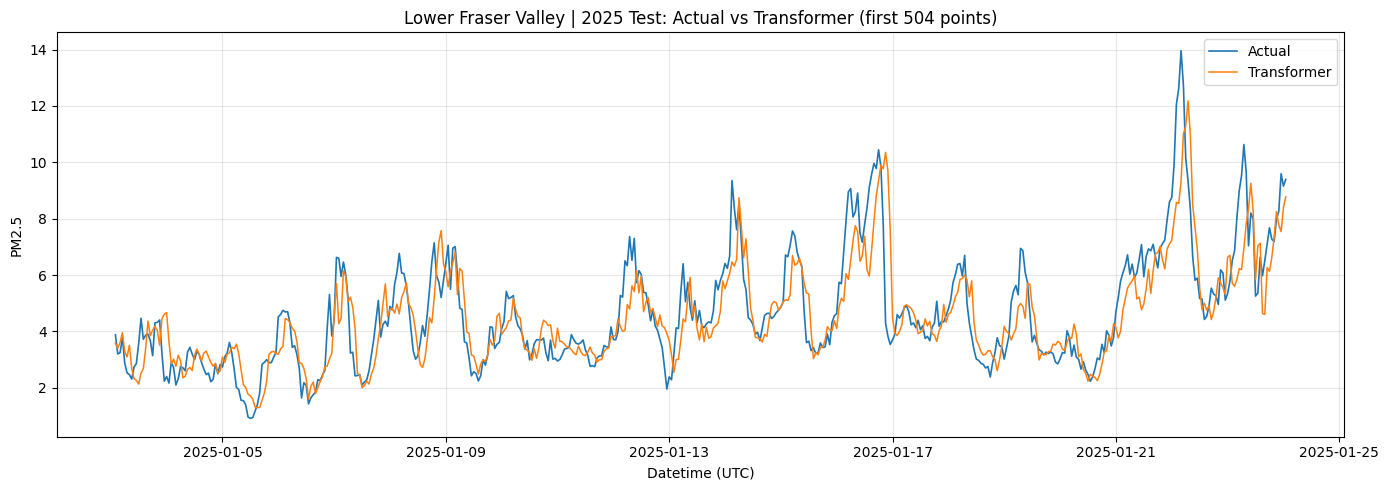

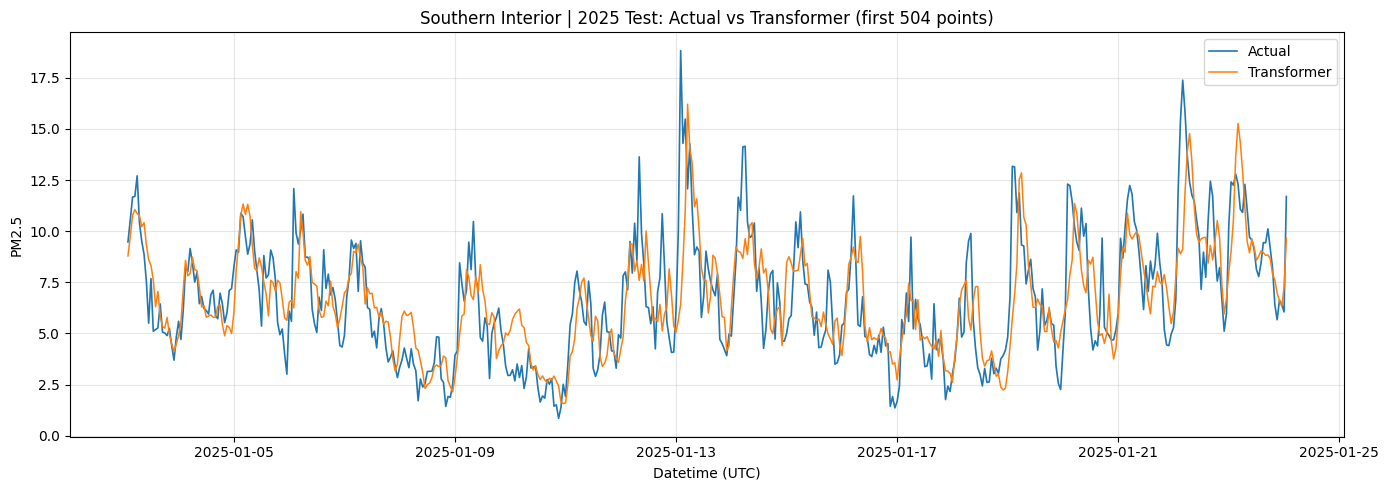

In [24]:
def plot_transformer(pred_df: pd.DataFrame, zone: str, max_hours=24*21):
    d = pred_df.sort_values("Datetime_UTC").copy()
    if max_hours is not None and len(d) > max_hours:
        d = d.iloc[:max_hours]

    plt.figure(figsize=(14, 5))
    plt.plot(d["Datetime_UTC"], d["y_true"], label="Actual", linewidth=1.2)
    plt.plot(d["Datetime_UTC"], d["y_pred"], label="Transformer", linewidth=1.1)
    plt.title(f"{zone} | 2025 Test: Actual vs Transformer (first {len(d)} points)")
    plt.xlabel("Datetime (UTC)")
    plt.ylabel("PM2.5")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

for z in zones:
    plot_transformer(preds_by_zone[z], z, max_hours=24*21)

In [ ]:
def alarm_metrics(pred_df, threshold=25):
    y_true_alarm = (pred_df["y_true"] >= threshold).astype(int)
    y_pred_alarm = (pred_df["y_pred"] >= threshold).astype(int)

    precision = precision_score(y_true_alarm, y_pred_alarm)
    recall = recall_score(y_true_alarm, y_pred_alarm)
    f1 = f1_score(y_true_alarm, y_pred_alarm)
    f2 = fbeta_score(y_true_alarm, y_pred_alarm, beta=2)

    return precision, recall, f1, f2
for z in zones:
    p, r, f, f2 = alarm_metrics(preds_by_zone[z], threshold=25)
    print(f"{z}: Precision={p:.3f}, Recall={r:.3f}, F1={f:.3f}, F2={f2:.3f}")

Lower Fraser Valley: Precision=0.583, Recall=0.538, F1=0.560, F2=0.547
Southern Interior: Precision=0.955, Recall=0.922, F1=0.939, F2=0.929


## LLaMA for Comparison ##

In [26]:
zones = sorted(df["Zone"].unique())
results = []
model_list = []
preds_by_zone = {}

for z in zones:
    dz = build_zone_frame(df[df["Zone"] == z])
    model, scaler, metrics, pred_df = train_one_zone(
        dz=dz,
        zone_name=z, 
        config=my_config, 
        features=FEATURES, 
        target=TARGET, 
        device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        model_name = "LLaMA"
    )
    model_list.append(model)
    results.append(metrics)
    preds_by_zone[z] = pred_df

pd.DataFrame(results)

/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_35938/1895822943.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)
/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_35938/1895822943.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Lower Fraser Valley] epoch 01 | lr=4.88e-04 | train_mse=29.0118 | test RMSE=2.6549 MAE=1.5000 R2=0.0980


/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_35938/1895822943.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Lower Fraser Valley] epoch 02 | lr=4.53e-04 | train_mse=18.6628 | test RMSE=1.8909 MAE=0.8946 R2=0.5424


/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_35938/1895822943.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


...

/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_35938/1895822943.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Southern Interior] epoch 09 | lr=1.71e-05 | train_mse=43.8340 | test RMSE=2.3093 MAE=1.3077 R2=0.7749


/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_35938/1895822943.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Southern Interior] epoch 10 | lr=5.00e-06 | train_mse=43.5152 | test RMSE=2.2978 MAE=1.3016 R2=0.7772


,Zone,RMSE,MAE,R2,N_test
0,Lower Fraser Valley,1.317794,0.699842,0.777763,8710
1,Southern Interior,2.297764,1.301562,0.777193,8710


## Time Window Experiment ##

In [ ]:
zones = sorted(df["Zone"].unique())
results = []
preds_by_zone = {}

for w in [12,24,48,72,96,168]:
    my_config.seq_len = w
    print(f"Training with seq_len={w} hours")
    dz = build_zone_frame(df[df["Zone"] == "Southern Interior"])
    model, scaler, metrics, pred_df = train_one_zone(
        dz=dz,
        zone_name=f"Southern Interior_seq{w}h", 
        config=my_config, 
        features=FEATURES, 
        target=TARGET, 
        device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        model_name = "GPT2"
    )
    results.append(metrics)
    p, r, f, f2 = alarm_metrics(pred_df, threshold=15)
    print(f"{z}: Precision={p:.3f}, Recall={r:.3f}, F1={f:.3f}, F2={f2:.3f}")



Training with seq_len=12 hours


/opt/homebrew/Caskroom/miniforge/base/envs/CS/lib/python3.10/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_93874/2093217315.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)
/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_93874/2093217315.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Southern Interior_seq12h] epoch 01 | lr=4.88e-04 | train_mse=102.9858 | test RMSE=4.8747 MAE=3.3325 R2=-0.0048


/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_93874/2093217315.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Southern Interior_seq12h] epoch 02 | lr=4.53e-04 | train_mse=58.6777 | test RMSE=2.5091 MAE=1.5212 R2=0.7338


...

[Southern Interior_seq168h] epoch 08 | lr=5.23e-05 | train_mse=12.2239 | test RMSE=1.9665 MAE=1.3847 R2=0.8385


/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_93874/2093217315.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Southern Interior_seq168h] epoch 09 | lr=1.71e-05 | train_mse=11.6479 | test RMSE=1.9492 MAE=1.3483 R2=0.8414


/var/folders/bg/8r_yclsn4cq6r178p98czlkc0000gn/T/ipykernel_93874/2093217315.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Southern Interior_seq168h] epoch 10 | lr=5.00e-06 | train_mse=11.2686 | test RMSE=1.9439 MAE=1.3312 R2=0.8422
Southern Interior: Precision=0.911, Recall=0.879, F1=0.895, F2=0.885
